# Quickstart

This notebook demonstrates how to use `mCRO` in the simplest configuration of the Recharge Oscillator (RO) model, featuring linear dynamics and additive white-noise forcing.

The RO model is written as:

$\displaystyle \frac{dT}{dt} = RT + F_{1}h + \sigma_{T}w_{T}$

$\displaystyle \frac{dh}{dt} = -\varepsilon h - F_{2}T + \sigma_{h}w_{h}$

where:

- $T$ is the sea surface temperature (SST) anomaly,
- $h$ is the thermocline depth anomaly (recharge-discharge state),
- $w_T$ and $w_h$ are independent white-noise processes,
- $R$, $F_1$, $F_2$, and $\varepsilon$ are dynamical RO feedback parameters,
- $\sigma_T$ and $\sigma_h$ control stochastic forcing amplitudes.

This notebook was contributed by [Soong-Ki Kim](https://csd.postech.ac.kr/professor).


## MATLAB setup


Clear the workspace before running the quickstart. Ensure that the CRO MATLAB functions are available on the MATLAB path.


In [ ]:
clear
clc

## Load precomputed RO parameters from ORAS5

In [ ]:
par=par_load("ORAS5","Linear-White-Additive");
par

par =
16×1 cell 배열
    {[ -0.0732]}
    {[  0.0179]}
    {[  1.2939]}
    {[  0.0088]}
    {0×0 double}
    {0×0 double}
    {0×0 double}
    {0×0 double}
    {[  0.2170]}
    {[  1.5548]}
    {0×0 double}
    {0×0 double}
    {0×0 double}
    {[       1]}
    {[       1]}
    {[       2]}


## Conduct RO simulations


In [ ]:
IC=[1.0;0.0];              % Initial conditions for T and h
N=12*100;                  % Simulation length in months (e.g., 100 years)
NE=2;                      % Number of ensemble members

[T,h]=RO_solver(par,IC,N,NE);

The solver returns T and h as [time × ensemble] matrices.


## Plot the outputs


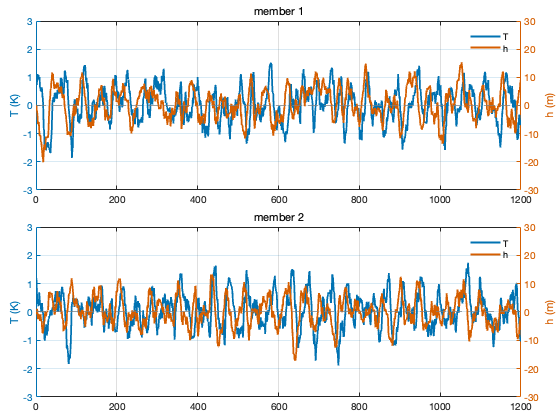

In [ ]:
time_axis=0:(N-1);

color_T=[0 114 178]/255;
color_h=[213 94 0]/255;

figure;
t=tiledlayout(2,1,'TileSpacing','compact','Padding','compact');

for i=1:NE
    ax=nexttile;

    % --- T (left axis) ---
    yyaxis left
    line1=plot(time_axis,T(:,i),'Color',color_T,'LineWidth',1.8,'DisplayName','T');
    ylabel('T (K)')
    ylim([-3 3])
    ax.YAxis(1).Color=color_T;
    hold on
    yline(0,'--','Color',[0.5 0.5 0.5],'LineWidth',0.8);

    % --- h (right axis) ---
    yyaxis right
    line2=plot(time_axis,h(:,i),'Color',color_h,'LineWidth',1.8,'DisplayName','h');
    ylabel('h (m)')
    ylim([-30 30])
    ax.YAxis(2).Color=color_h;

    legend([line1 line2],{'T','h'},'Location','northeast','Box','off')
    title(sprintf('member %d',i))
    grid on
end